### Headers

In [2]:
import numpy as np
import matplotlib.pyplot as plt

### Dataset

In [4]:
# Dataset
train_data=np.loadtxt("trian.txt",delimiter=",")
dev_data=np.loadtxt("dev.txt",delimiter=",")

X_train=train_data[:,:2]
y_train=train_data[:,2].astype(int)

X_dev=dev_data[:,:2]
y_dev=dev_data[:,2].astype(int)

print("Classes: ",np.unique(y_train))

Classes:  [1 2 3]


### Estimation of parameters:

mean: $$\hat{\mu} = \frac{1}{N} \sum_{i=1}^{N} \mathbf{x}_i$$

covariance: $$\mathbf{\Sigma} = \frac{1}{N} \sum_{i=1}^{N} (\mathbf{x}_i - \hat{\mu})(\mathbf{x}_i - \hat{\mu})^T $$


In [5]:
def estimate_parameters(X):
    N_sample=X.shape[0]
    # sum(x)/N
    mean=np.sum(X, axis=0)/N_sample
    # sum((x-mean)(x-mean)T)/N
    X_center=X-mean
    covariance=(X_center.T @ X_center)/N_sample
    return mean,covariance

X_class1=X_train[y_train==1]
X_class2=X_train[y_train==2]
X_class3=X_train[y_train==3]

mu1_est,cov1_est=estimate_parameters(X_class1)
mu2_est,cov2_est=estimate_parameters(X_class2)
mu3_est,cov3_est=estimate_parameters(X_class3)

print("\nEstimated parameters")
print("\nClass 1:")
print("Mean =",mu1_est)
print("Covariance =")
print(cov1_est)

print("\nClass 2:")
print("Mean =",mu2_est)
print("Covariance =")
print(cov2_est)

print("\nClass 3:")
print("Mean =",mu3_est)
print("Covariance =")
print(cov3_est)


Estimated parameters

Class 1:
Mean = [ 576.65177143 1445.08757143]
Covariance =
[[22855.03091458  4440.74545716]
 [ 4440.74545716 62442.17633324]]

Class 2:
Mean = [ 385.13434286 1926.62877143]
Covariance =
[[19578.821412   -9471.68881695]
 [-9471.68881695 57805.1777062 ]]

Class 3:
Mean = [ 426.32365714 1259.74385714]
Covariance =
[[ 28790.16643634  43234.23906704]
 [ 43234.23906704 178558.61781398]]


### Multivariate Gaussian Log-Likelihood Function
$$\ln p(\mathbf{x} \mid C_i) = -\frac{1}{2} \left[ \ln \vert{}\mathbf{\Sigma}_i\vert{} + (\mathbf{x} - \mathbf{\mu}_i)^T \mathbf{\Sigma}_i^{-1} (\mathbf{x} - \mathbf{\mu}_i) + d \ln(2\pi) \right]$$

In [6]:
def gaussian_logpdf(x,mean,cov):
  # logp(x∣Ci​)=−1/2​[log∣Σi​∣+(x−μi​)T (Σi−1) ​(x−μi​)+dlog(2π)]
  diff=x-mean
  determinant=np.linalg.det(cov)
  inverse=np.linalg.inv(cov)
  mahalanobis=diff.T @ inverse @ diff
  log_prob=-0.5*(np.log(determinant)+mahalanobis+2*np.log(2*np.pi))
  return log_prob

### Classification Test Data

In [7]:
def classify(X):
  predictions=[]
  for x in X:
    log_p1=gaussian_logpdf(x,mu1_est,cov1_est)
    log_p2=gaussian_logpdf(x,mu2_est,cov2_est)
    log_p3=gaussian_logpdf(x,mu3_est,cov3_est)

    predicted_class=np.argmax([log_p1,log_p2,log_p3])+1
    predictions.append(predicted_class)

  return np.array(predictions)

predicted_labels=classify(X_dev)
print("\nPredicted Labels: ")
print(predicted_labels)
print("\nActual labels: ")
print(y_dev)


Predicted Labels: 
[1 1 2 1 1 1 3 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 3 1 1 1 1 1 3 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 3 3 1 3 1 1 1 1 1 1 2 1 1 3 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 2 3 2 1 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 3 2 2 2 2 2 1 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 1 2 2 2 1 1 2 2 2 2 1 2 2 2 2 2 2 2 2 1 1 2 2 2 2 1 2
 2 2 3 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 2 2 2 2 2 2
 2 1 2 2 2 2 2 2 2 2 2 2 2 1 2 3 1 3 3 2 3 1 2 1 3 1 3 3 2 1 1 3 2 3 3 3 3
 3 3 3 1 3 1 3 1 1 3 3 3 3 1 3 3 1 1 2 3 3 3 1 3 3 3 3 3 1 3 3 1 3 3 3 2 3
 3 3 1 2 3 1 3 3 1 3 3 3 1 2 3 1 3 2 3 1 3 3 3 3 3 3 2 3 3 3 3 1 3 3 3 3 1
 3 2 3 3]

Actual labels: 
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 

### Confusion Matrix

In [8]:
confusion_matrix=np.zeros((3,3),dtype=int)
for actual,predicted in zip(y_dev,predicted_labels):
   confusion_matrix[actual-1,predicted-1]+=1
print("\nConfusion matrix: ")
print(confusion_matrix)

correct=np.trace(confusion_matrix)
total=np.sum(confusion_matrix)
accuracy=(correct/total)*100

print("\nCorrect Predictions: ",correct)
print("Total Samples: ",total)
print("Accuracy: ",accuracy,"%")


Confusion matrix: 
[[85  7  8]
 [11 86  3]
 [24 11 65]]

Correct Predictions:  236
Total Samples:  300
Accuracy:  78.66666666666666 %


### Decision Boundary

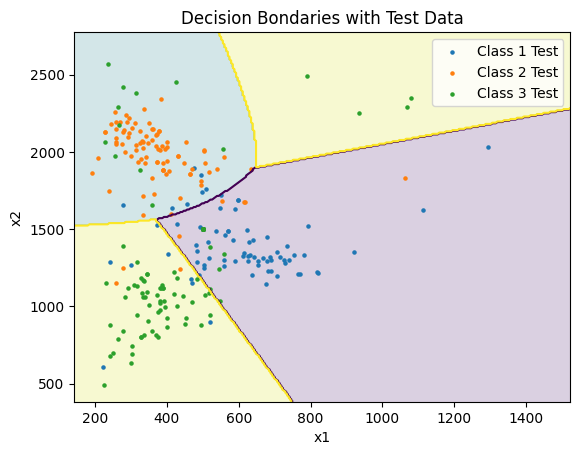

In [9]:
#Decision Boundaries
x_min=min(X_train[:,0].min(),X_dev[:,0].min())-50
x_max=max(X_train[:,0].max(),X_dev[:,0].max())+50

y_min=min(X_train[:,1].min(),X_dev[:,1].min())-50
y_max=max(X_train[:,1].max(),X_dev[:,1].max())+50

x_values=np.linspace(x_min,x_max,300)
y_values=np.linspace(y_min,y_max,300)

X_grid,Y_grid=np.meshgrid(x_values,y_values)

grid_points=np.column_stack((X_grid.ravel(),Y_grid.ravel()))

grid_predictions=classify(grid_points)
decision_grid=grid_predictions.reshape(X_grid.shape)

plt.contourf(X_grid,Y_grid,decision_grid,alpha=0.2)
plt.contour(X_grid,Y_grid,decision_grid,levels=[1.5,2.5])

plt.scatter(X_dev[y_dev==1,0],X_dev[y_dev==1,1],s=5,label="Class 1 Test")
plt.scatter(X_dev[y_dev==2,0],X_dev[y_dev==2,1],s=5,label="Class 2 Test")
plt.scatter(X_dev[y_dev==3,0],X_dev[y_dev==3,1],s=5,label="Class 3 Test")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Decision Bondaries with Test Data")
plt.legend()
plt.show()

### Receiver Operating Characteristics

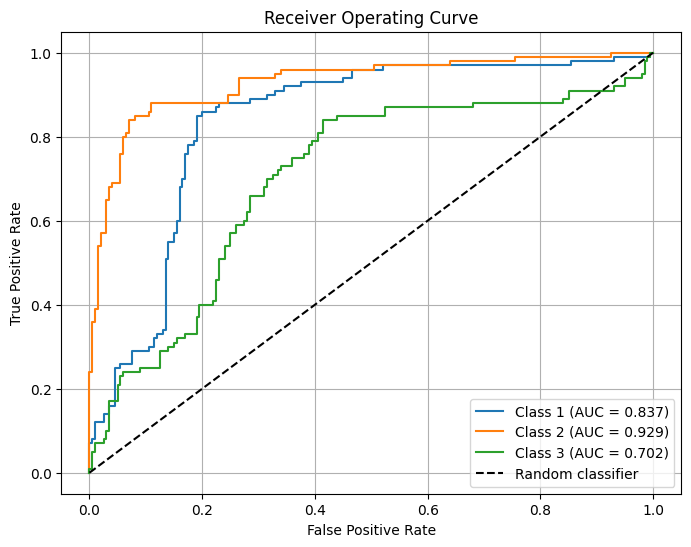

In [10]:
X_test=X_dev
scores=[]
for x in X_test:
  p1=gaussian_logpdf(x,mu1_est,cov1_est)
  p2=gaussian_logpdf(x,mu2_est,cov2_est)
  p3=gaussian_logpdf(x,mu3_est,cov3_est)
  scores.append([p1,p2,p3])
scores=np.array(scores)

def calculate_roc(true_labels,scores,class_label):
  actual=(true_labels==class_label).astype(int)
  order=np.argsort(scores)[::-1]
  actual=actual[order]
  P=np.sum(actual==1)
  N=np.sum(actual==0)
  TP=np.cumsum(actual==1)
  FP=np.cumsum(actual==0)
  TPR=np.concatenate(([0],TP/P,[1]))
  FPR=np.concatenate(([0],FP/N,[1]))
  return FPR,TPR

plt.figure(figsize=(8, 6))

for i in range(3):
  class_label=i+1
  FPR,TPR=calculate_roc(y_dev,scores[:,i],class_label)
  AUC=np.sum((FPR[1:]-FPR[:-1])*(TPR[1:]+TPR[:-1])/2)
  plt.plot(FPR,TPR,label=f'Class {class_label} (AUC = {AUC:.3f})')
plt.plot([0, 1], [0, 1], 'k--',label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Curve")
plt.legend()
plt.grid(True)
plt.show()